In [ ]:
import pandas as pd

df = pd.read_csv("Q03_food_delivery.csv")

In [ ]:
print("First 5 rows:")
print(df.head())

First 5 rows:
  trip_id  pickup_timestamp     area  distance_km traffic_condition  \
0  FD0001  2026-01-16 21:27     West          NaN              High   
1  FD0002  2026-03-22 22:12     East         5.53              High   
2  FD0003  2026-03-07 10:08  Central         5.86              High   
3  FD0004  2026-03-25 03:54  Central         4.16          Moderate   
4  FD0005  2026-07-07 20:24  Central         8.76          Moderate   

   delivery_time_min  promised_time_min  
0               28.8                 35  
1               44.2                 35  
2               51.0                 35  
3               26.3                 35  
4               52.2                 35  


In [ ]:
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(123, 7)


In [ ]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   trip_id            123 non-null    object 
 1   pickup_timestamp   123 non-null    object 
 2   area               122 non-null    object 
 3   distance_km        122 non-null    float64
 4   traffic_condition  122 non-null    object 
 5   delivery_time_min  123 non-null    float64
 6   promised_time_min  123 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 6.9+ KB
None


In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
trip_id              0
pickup_timestamp     0
area                 1
distance_km          1
traffic_condition    1
delivery_time_min    0
promised_time_min    0
dtype: int64


In [ ]:
#pickup time stamp
missing_timestamp = df["pickup_timestamp"].isnull().sum()
print("\nMissing GPS/Pickup Timestamps:", missing_timestamp)
if missing_timestamp > 0:
    print("Missing timestamps found. Correction is required.")
else:
    print("No missing timestamps found. No timestamp correction is required.")


Missing GPS/Pickup Timestamps: 0
No missing timestamps found. No timestamp correction is required.


In [ ]:
print("\nRows containing missing values:")
print(df[df.isnull().any(axis=1)])


Rows containing missing values:
   trip_id  pickup_timestamp  area  distance_km traffic_condition  \
0   FD0001  2026-01-16 21:27  West          NaN              High   
6   FD0007  2026-06-05 21:19   NaN        12.53               Low   
97  FD0098  2026-02-22 22:35  West         9.60               NaN   

    delivery_time_min  promised_time_min  
0                28.8                 35  
6                43.4                 35  
97               50.2                 35  


In [ ]:
df["area"] = df["area"].fillna(df["area"].mode()[0])

In [ ]:
df["traffic_condition"] = df["traffic_condition"].fillna(
    df["traffic_condition"].mode()[0]
)

In [ ]:
df["distance_km"] = df["distance_km"].fillna(
    df["distance_km"].median()
)

In [ ]:
print("\nMissing values after treatment:")
print(df.isnull().sum())


Missing values after treatment:
trip_id              0
pickup_timestamp     0
area                 0
distance_km          0
traffic_condition    0
delivery_time_min    0
promised_time_min    0
dtype: int64


In [ ]:
#inspect the distance statistics
print("Distance Statistics:")
print(df["distance_km"].describe())

Distance Statistics:
count    123.000000
mean       7.722886
std        5.292321
min        0.590000
25%        3.980000
50%        6.485000
75%       10.215000
max       26.120000
Name: distance_km, dtype: float64


In [ ]:
#EDA
Q1 = df["distance_km"].quantile(0.25)
Q3 = df["distance_km"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 3.9799999999999995
Q3: 10.215
IQR: 6.235
Lower Bound: -5.372500000000001
Upper Bound: 19.567500000000003


In [ ]:
outliers = df[
    (df["distance_km"] < lower_bound) |
    (df["distance_km"] > upper_bound)
]

print("\nUnrealistic distance records:")
print(outliers[["trip_id", "distance_km"]])


Unrealistic distance records:
    trip_id  distance_km
15   FD0016        20.18
66   FD0067        25.08
91   FD0092        24.82
108  FD0109        26.12


In [ ]:
df = df[
    (df["distance_km"] >= lower_bound) &
    (df["distance_km"] <= upper_bound)
]

print("\nShape after removing unrealistic distances:")
print(df.shape)


Shape after removing unrealistic distances:
(119, 7)


In [ ]:
#suitable diatance bands
bins = [0, 5, 10, 15, 20]
labels = [
    "0-5 km",
    "5-10 km",
    "10-15 km",
    "15-20 km"
]
df["distance_band"] = pd.cut(
    df["distance_km"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
print(df[["trip_id", "distance_km", "distance_band"]].head(20))

   trip_id  distance_km distance_band
0   FD0001        6.485       5-10 km
1   FD0002        5.530       5-10 km
2   FD0003        5.860       5-10 km
3   FD0004        4.160        0-5 km
4   FD0005        8.760       5-10 km
5   FD0006        8.470       5-10 km
6   FD0007       12.530      10-15 km
7   FD0008       10.030      10-15 km
8   FD0009        9.220       5-10 km
9   FD0010        2.170        0-5 km
10  FD0011       14.290      10-15 km
11  FD0012        7.560       5-10 km
12  FD0013        1.210        0-5 km
13  FD0014        1.780        0-5 km
14  FD0015       16.810      15-20 km
16  FD0017        2.300        0-5 km
17  FD0018        4.040        0-5 km
18  FD0019        6.370       5-10 km
19  FD0020        3.590        0-5 km
20  FD0021       13.780      10-15 km


In [ ]:
print("\nTrips in each distance band:")
print(df["distance_band"].value_counts().sort_index())


Trips in each distance band:
distance_band
0-5 km      41
5-10 km     49
10-15 km    21
15-20 km     8
Name: count, dtype: int64


In [ ]:
#delay indicator
df["delay_indicator"] = (
    df["delivery_time_min"] > df["promised_time_min"]
).astype(int)

print(df[
    ["trip_id", "delivery_time_min",
     "promised_time_min", "delay_indicator"]
].head(20))

   trip_id  delivery_time_min  promised_time_min  delay_indicator
0   FD0001               28.8                 35                0
1   FD0002               44.2                 35                1
2   FD0003               51.0                 35                1
3   FD0004               26.3                 35                0
4   FD0005               52.2                 35                1
5   FD0006               38.5                 35                1
6   FD0007               43.4                 35                1
7   FD0008               40.8                 35                1
8   FD0009               43.4                 35                1
9   FD0010               12.8                 35                0
10  FD0011               60.1                 35                1
11  FD0012               24.3                 35                0
12  FD0013               18.1                 35                0
13  FD0014               12.2                 35                0
14  FD0015

In [ ]:
df["delay_status"] = df["delay_indicator"].map({
    0: "On Time",
    1: "Late"
})
print("\nDelay Status:")
print(df["delay_status"].value_counts())


Delay Status:
delay_status
Late       61
On Time    58
Name: count, dtype: int64


In [ ]:
#eda
distance_analysis = df.groupby("distance_band")["delivery_time_min"].agg(
    ["count", "mean", "min", "max"]
)

print(distance_analysis)

               count       mean   min   max
distance_band                              
0-5 km            41  24.636585  10.0  42.2
5-10 km           49  36.634694  13.3  54.6
10-15 km          21  51.628571  40.8  70.1
15-20 km           8  64.050000  50.2  89.2


/tmp/ipykernel_2235/2486850346.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distance_analysis = df.groupby("distance_band")["delivery_time_min"].agg(


In [ ]:

delay_by_distance = df.groupby("distance_band")["delay_indicator"].agg(
    ["count", "sum", "mean"]
)

delay_by_distance["delay_percentage"] = (
    delay_by_distance["mean"] * 100
)

print(delay_by_distance)

               count  sum      mean  delay_percentage
distance_band                                        
0-5 km            41    5  0.121951         12.195122
5-10 km           49   27  0.551020         55.102041
10-15 km          21   21  1.000000        100.000000
15-20 km           8    8  1.000000        100.000000


/tmp/ipykernel_2235/3895141384.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_by_distance = df.groupby("distance_band")["delay_indicator"].agg(


/tmp/ipykernel_2235/2004382217.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("distance_band")["delivery_time_min"].mean().plot(


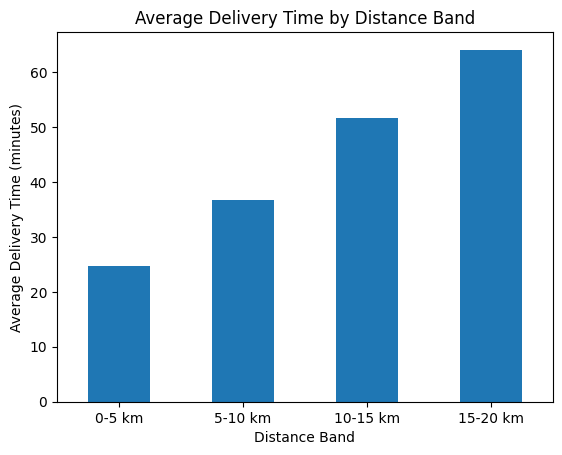

In [ ]:

import matplotlib.pyplot as plt
df.groupby("distance_band")["delivery_time_min"].mean().plot(
    kind="bar"
)
plt.title("Average Delivery Time by Distance Band")
plt.xlabel("Distance Band")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
traffic_analysis = df.groupby("traffic_condition")["delivery_time_min"].agg(
    ["count", "mean", "min", "max"]
)

print("Delivery Time by Traffic Condition:")
print(traffic_analysis)

Delivery Time by Traffic Condition:
                   count       mean   min   max
traffic_condition                              
High                  27  46.003704  24.4  89.2
Low                   41  30.060976  10.0  56.2
Moderate              51  37.788235  12.8  70.5


In [ ]:
delay_by_traffic = df.groupby("traffic_condition")["delay_indicator"].agg(
    ["count", "sum", "mean"]
)

delay_by_traffic["delay_percentage"] = (
    delay_by_traffic["mean"] * 100
)

print("\nDelay by Traffic Condition:")
print(delay_by_traffic)


Delay by Traffic Condition:
                   count  sum      mean  delay_percentage
traffic_condition                                        
High                  27   22  0.814815         81.481481
Low                   41   14  0.341463         34.146341
Moderate              51   25  0.490196         49.019608


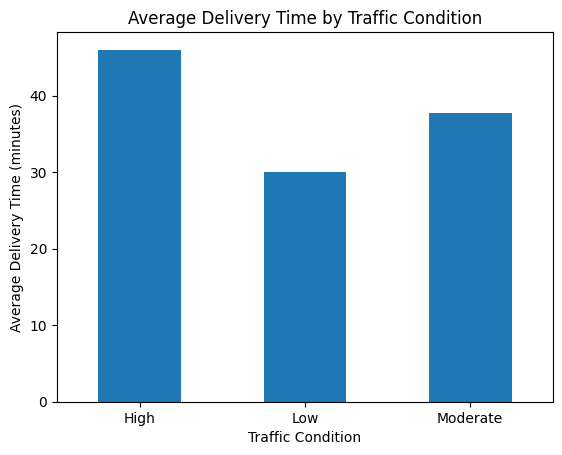

In [ ]:
df.groupby("traffic_condition")["delivery_time_min"].mean().plot(
    kind="bar"
)

plt.title("Average Delivery Time by Traffic Condition")
plt.xlabel("Traffic Condition")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
df.groupby('area')['delivery_time_min'].mean().plot(kind='bar')

plt.title('Average Delivery Time by Area')
plt.xlabel('Area')
plt.ylabel('Average Delivery Time (minutes)')
plt.xticks(rotation=0)
plt.show()

In [ ]:
import pandas as pd

# Load original dataset
df = pd.read_csv("Q03_food_delivery.csv")

# 1. Handle missing values
df["area"] = df["area"].fillna(df["area"].mode()[0])

df["traffic_condition"] = df["traffic_condition"].fillna(
    df["traffic_condition"].mode()[0]
)

df["distance_km"] = df["distance_km"].fillna(
    df["distance_km"].median()
)

# 2. Remove duplicate rows
df = df.drop_duplicates()

# 3. Remove unrealistic distances using IQR
Q1 = df["distance_km"].quantile(0.25)
Q3 = df["distance_km"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df = df[df["distance_km"] <= upper_bound]

# 4. Create distance bands
df["distance_band"] = pd.cut(
    df["distance_km"],
    bins=[0, 5, 10, 15, 20],
    labels=["0-5 km", "5-10 km", "10-15 km", "15-20 km"],
    include_lowest=True
)

# 5. Create delay indicator
df["delay_indicator"] = (
    df["delivery_time_min"] > df["promised_time_min"]
).astype(int)

# 6. Create delay status
df["delay_status"] = df["delay_indicator"].map({
    0: "On Time",
    1: "Late"
})

# 7. Save cleaned dataset
df.to_csv("cleaned_food_delivery.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Final shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Cleaned dataset saved successfully!
Final shape: (116, 10)

Missing values:
trip_id              0
pickup_timestamp     0
area                 0
distance_km          0
traffic_condition    0
delivery_time_min    0
promised_time_min    0
distance_band        0
delay_indicator      0
delay_status         0
dtype: int64
